In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-06-18 12:58:09.671056


In [10]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 200
lat.get_bz(nk, ibz=True)
lat.get_e_k()

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, niw, nk)
scba.run(0.1, beta, n, ibz=True)

S_iwk = lat.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

[[0.         0.        ]
 [0.03141593 0.        ]
 [0.06283185 0.        ]
 ...
 [3.11017673 3.11017673]
 [3.14159265 3.11017673]
 [3.14159265 3.14159265]]


AttributeError: 'LATTICE' object has no attribute 'ibz_w_k'

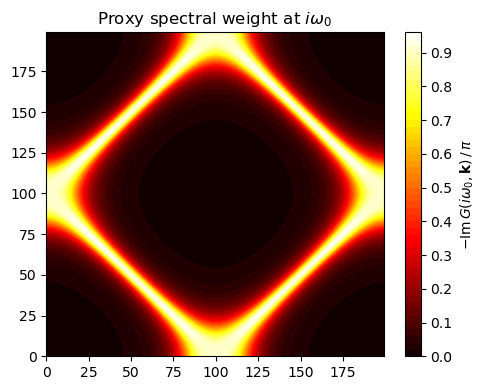

In [ ]:
# G(iω_n, k) = 1 / (iω_n - ε_k - Σ(iω_n, k))
# At n=0 (first positive Matsubara freq): ω_0 = π/β

omega_0 = np.pi / beta  # = π · T

# ε_k on full BZ, shape (nk, nk)
e_k_full = lat.unfold_f_k(lat.e_k)   # adjust to your API

# Σ(iω_0, k) — already computed above
# S_k_n0 shape (nk, nk), complex

G_k_n0 = 1.0 / (1j * omega_0 - e_k_full - S_iwk[0])

# Proxy spectral weight: -Im G(iω_0, k) / π
A_proxy = -G_k_n0.imag / np.pi

plt.figure(figsize=(5, 4))
plt.contourf(A_proxy.reshape(nk,nk), levels=50, cmap='hot')
plt.colorbar(label=r'$-\mathrm{Im}\, G(i\omega_0,\mathbf{k})\,/\,\pi$')
plt.title(r'Proxy spectral weight at $i\omega_0$')
plt.tight_layout()
plt.show()

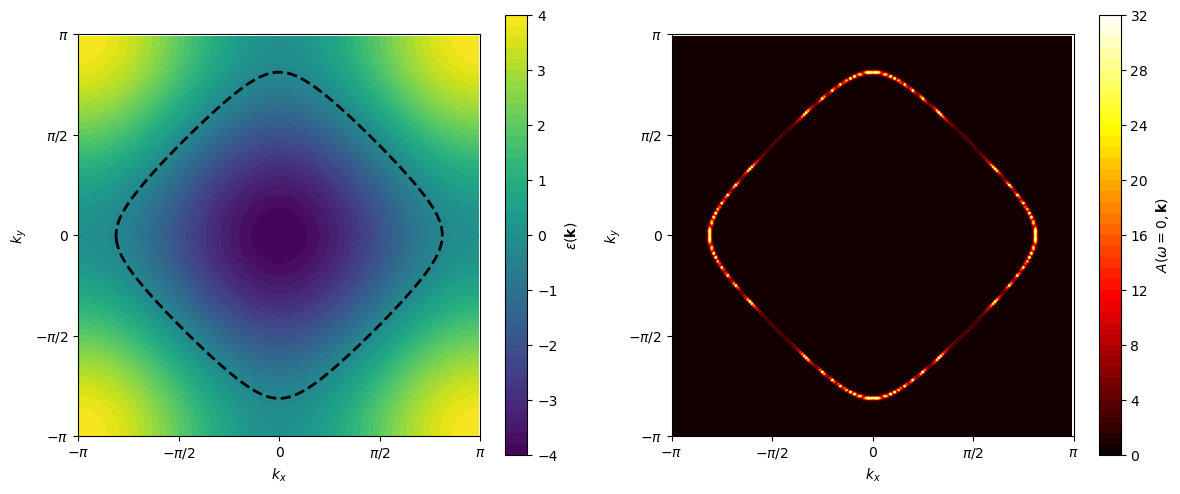

In [ ]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


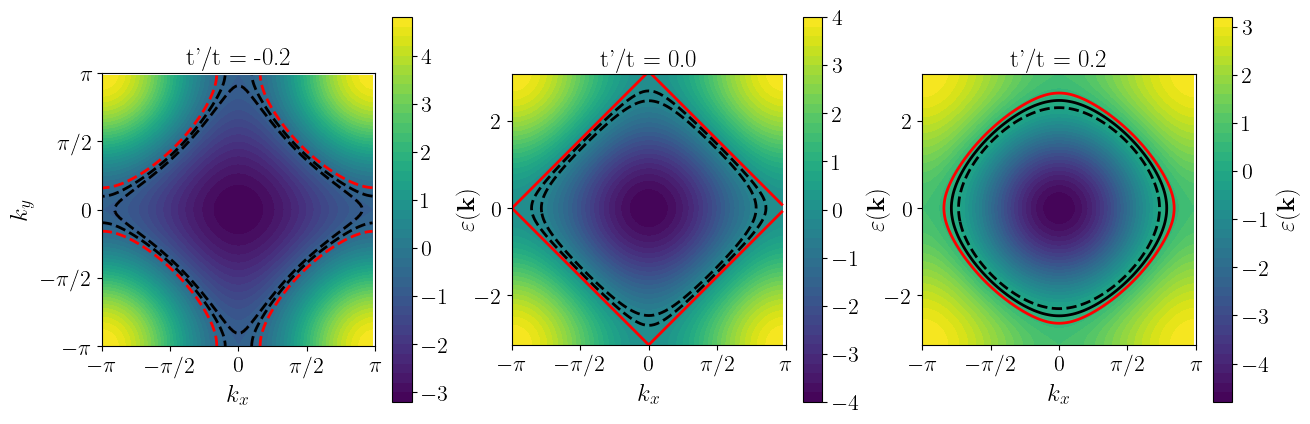

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

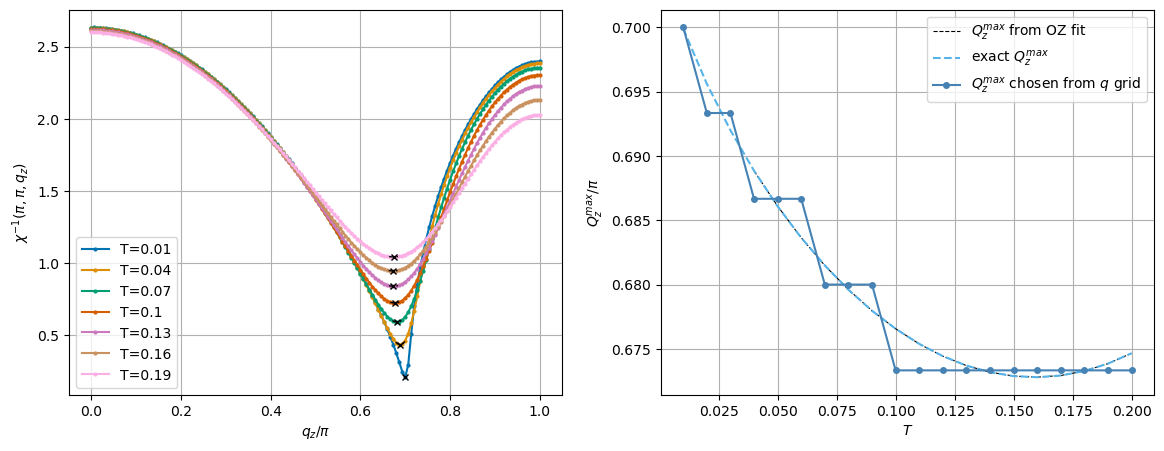

In [ ]:
n = 0.745
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 300
lat = LATTICE()
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'lindhard', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z/\pi$')

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])
    plot_every = 3
    if i%plot_every == 0:
        ax[0].plot(qz_grid, data['invchi_grid'], 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz_ref[-1]-data['xi_range'][-1], Qz_ref[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_ref[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z$ from OZ fit')
ax[1].plot(T_list, Qz_ref, '--', color=color_list[9], label='exact $Q_z$')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z$ chosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

Starting serial run at: 2026-06-18 11:39:26.935923
Starting serial run at: 2026-06-18 11:39:26.939690
Starting serial run at: 2026-06-18 11:39:26.999127
Starting serial run at: 2026-06-18 11:39:27.065543
Starting serial run at: 2026-06-18 11:39:27.111823


/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxf

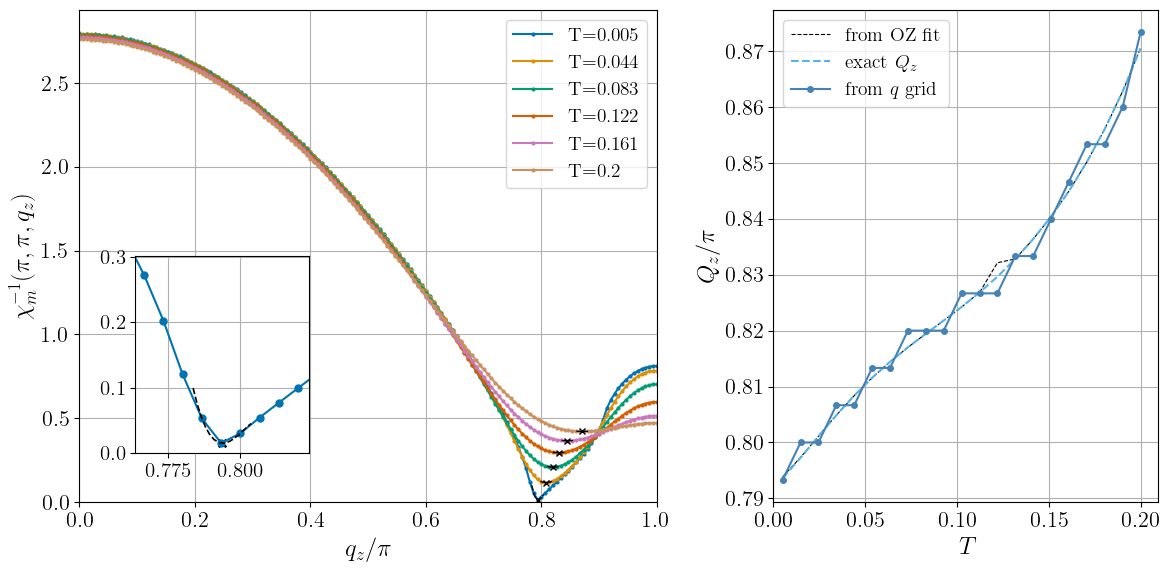

In [6]:
n = 0.848
T_list = np.linspace(0.005, 0.2, 21)
U = 3

nk = 300
lat = LATTICE(tp=0.1)
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'local', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2])

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1])
]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}_m(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z/\pi$')

axins = inset_axes(
    ax[0],
    width="30%",
    height="40%",
    bbox_to_anchor=(0.08, 0.08, 1, 1),
    bbox_transform=ax[0].transAxes,
    loc="lower left"
)

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]

Qz = []
Qz_ref = []
Qz_fit = []

for i, data in enumerate(results_list):

    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])

    plot_every = 4
    if i % plot_every == 0:
        ax[0].plot(
            qz_grid,
            data['invchi_grid'],
            'o-',
            markersize=2,
            label=f'T={T_list[i]:.4g}',
            color=color_list[i//plot_every]
        )

        qz_grid_fitted = np.linspace(
            Qz_ref[-1]-data['xi_range'][-1],
            Qz_ref[-1]+data['xi_range'][-1],
            data['xi_pts']
        )

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        ax[0].plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1
        )

        ax[0].plot(
            Qz_ref[-1],
            data['invchi'],
            'x',
            markersize=4,
            color='black'
        )

    if i == 0:

        qz_grid_fitted = np.linspace(
            Qz_ref[-1] - data['xi_range'][-1],
            Qz_ref[-1] + data['xi_range'][-1],
            data['xi_pts']
        )

        mask = np.abs(qz_grid - Qz_ref[-1]) < 4e-2

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        axins.plot(
            qz_grid[mask],
            data['invchi_grid'][mask],
            'o-',
            markersize=5,
            label=f'{T_list[i]:.3f}',
            color=color_list[0],
            alpha=1-i*0.1
        )

        axins.scatter(
            Qz_ref[-1],
            data['invchi'],
            marker='x',
            s=30,
            linewidths=1.8,
            color='black'
        )

        axins.plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1.2
        )

        axins.grid(True)
        axins.tick_params(labelsize=15)
        axins.set_xlim(Qz_ref[0]-3e-2, Qz_ref[0]+3e-2)

        idx_max = np.argmax(data['invchi_grid'][mask])
        axins.set_ylim(0, (data['invchi_grid'][mask][idx_max]+max(np.delete(data['invchi_grid'][mask], idx_max)))/2)

ax[1].plot(
    T_list,
    Qz_fit,
    '--',
    color='black',
    linewidth=0.8,
    label='from OZ fit'
)

ax[1].plot(
    T_list,
    Qz_ref,
    '--',
    color=color_list[9],
    label='exact $Q_z$'
)

ax[1].plot(
    T_list,
    Qz,
    'o-',
    markersize=4,
    color='steelblue',
    label='from $q$ grid'
)

for a in ax:
    a.grid()
    
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper left')

ax[1].set_xlim(left=0.)
ax[0].set_xlim(0,1)
ax[0].set_ylim(bottom=0.)

fig.tight_layout()
plt.show()

Starting serial run at: 2026-06-18 12:08:07.981956
Starting serial run at: 2026-06-18 12:08:07.984756
Starting serial run at: 2026-06-18 12:08:07.992311
Starting serial run at: 2026-06-18 12:08:08.041742
Starting serial run at: 2026-06-18 12:08:08.137424
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

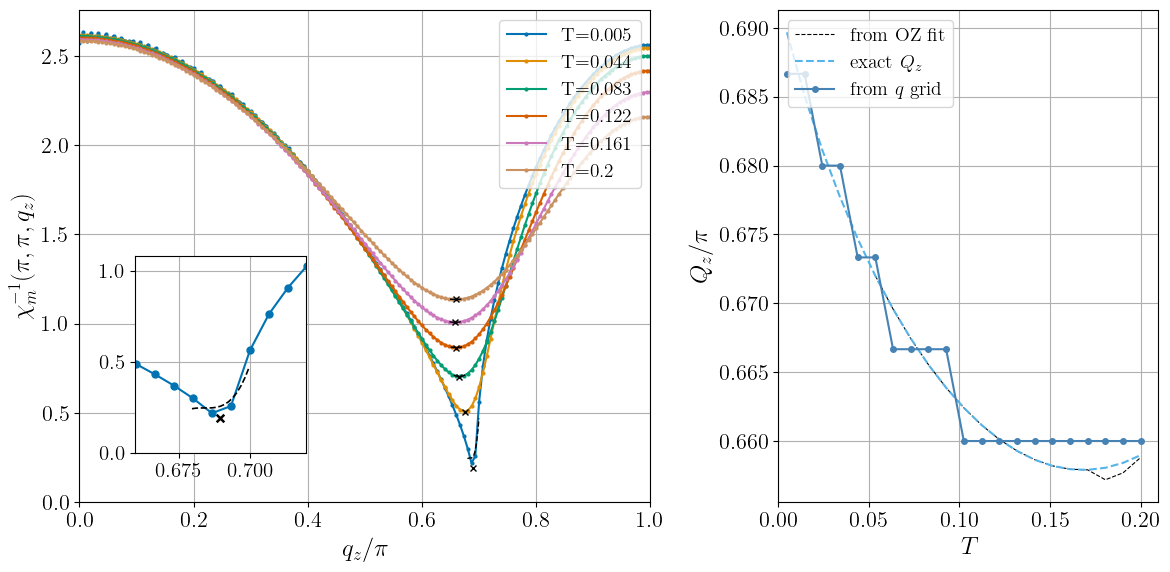

In [2]:
n = 0.735
T_list = np.linspace(0.005, 0.2, 21)
U = 3

nk = 300
lat = LATTICE()
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'local', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2])

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1])
]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}_m(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z/\pi$')

axins = inset_axes(
    ax[0],
    width="30%",
    height="40%",
    bbox_to_anchor=(0.08, 0.08, 1, 1),
    bbox_transform=ax[0].transAxes,
    loc="lower left"
)

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]

Qz = []
Qz_ref = []
Qz_fit = []

for i, data in enumerate(results_list):

    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])

    plot_every = 4
    if i % plot_every == 0:
        ax[0].plot(
            qz_grid,
            data['invchi_grid'],
            'o-',
            markersize=2,
            label=f'T={T_list[i]:.4g}',
            color=color_list[i//plot_every]
        )

        qz_grid_fitted = np.linspace(
            Qz_ref[-1]-data['xi_range'][-1],
            Qz_ref[-1]+data['xi_range'][-1],
            data['xi_pts']
        )

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        ax[0].plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1
        )

        ax[0].plot(
            Qz_ref[-1],
            data['invchi'],
            'x',
            markersize=4,
            color='black'
        )

    if i == 0:

        qz_grid_fitted = np.linspace(
            Qz_ref[-1] - data['xi_range'][-1],
            Qz_ref[-1] + data['xi_range'][-1],
            data['xi_pts']
        )

        mask = np.abs(qz_grid - Qz_ref[-1]) < 4e-2

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        axins.plot(
            qz_grid[mask],
            data['invchi_grid'][mask],
            'o-',
            markersize=5,
            label=f'{T_list[i]:.3f}',
            color=color_list[0],
            alpha=1-i*0.1
        )

        axins.scatter(
            Qz_ref[-1],
            data['invchi'],
            marker='x',
            s=30,
            linewidths=1.8,
            color='black'
        )

        axins.plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1.2
        )

        axins.grid(True)
        axins.tick_params(labelsize=15)
        axins.set_xlim(Qz_ref[0]-3e-2, Qz_ref[0]+3e-2)

        idx_max = np.argmax(data['invchi_grid'][mask])
        axins.set_ylim(0, (data['invchi_grid'][mask][idx_max]+max(np.delete(data['invchi_grid'][mask], idx_max)))/2)

ax[1].plot(
    T_list,
    Qz_fit,
    '--',
    color='black',
    linewidth=0.8,
    label='from OZ fit'
)

ax[1].plot(
    T_list,
    Qz_ref,
    '--',
    color=color_list[9],
    label='exact $Q_z$'
)

ax[1].plot(
    T_list,
    Qz,
    'o-',
    markersize=4,
    color='steelblue',
    label='from $q$ grid'
)

for a in ax:
    a.grid()
    
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper left')

ax[1].set_xlim(left=0.)
ax[0].set_xlim(0,1)
ax[0].set_ylim(bottom=0.)

fig.tight_layout()
plt.show()

Starting serial run at: 2026-06-18 12:58:23.512619
Starting serial run at: 2026-06-18 12:58:23.559304
Starting serial run at: 2026-06-18 12:58:23.589087
Starting serial run at: 2026-06-18 12:58:23.604073
Starting serial run at: 2026-06-18 12:58:23.611385
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

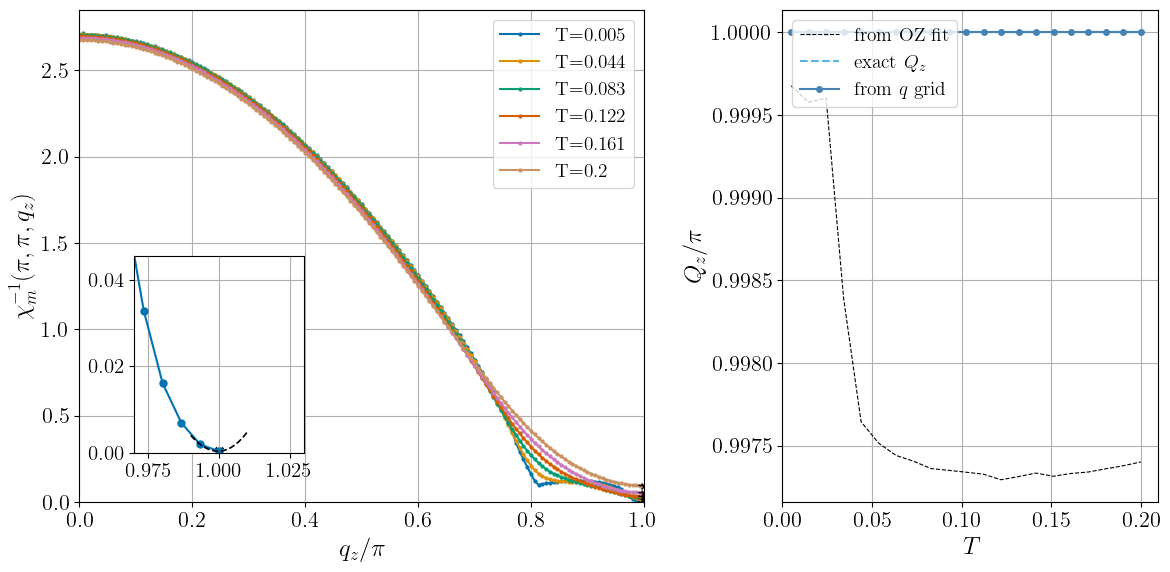

In [2]:
n = 0.8849
T_list = np.linspace(0.005, 0.2, 21)
U = 3

nk = 300
lat = LATTICE(tp=0.2)
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'local', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2])

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1])
]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}_m(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z/\pi$')

axins = inset_axes(
    ax[0],
    width="30%",
    height="40%",
    bbox_to_anchor=(0.08, 0.08, 1, 1),
    bbox_transform=ax[0].transAxes,
    loc="lower left"
)

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]

Qz = []
Qz_ref = []
Qz_fit = []

for i, data in enumerate(results_list):

    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])

    plot_every = 4
    if i % plot_every == 0:
        ax[0].plot(
            qz_grid,
            data['invchi_grid'],
            'o-',
            markersize=2,
            label=f'T={T_list[i]:.4g}',
            color=color_list[i//plot_every]
        )

        qz_grid_fitted = np.linspace(
            Qz_ref[-1]-data['xi_range'][-1],
            Qz_ref[-1]+data['xi_range'][-1],
            data['xi_pts']
        )

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        ax[0].plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1
        )

        ax[0].plot(
            Qz_ref[-1],
            data['invchi'],
            'x',
            markersize=4,
            color='black'
        )

    if i == 0:

        qz_grid_fitted = np.linspace(
            Qz_ref[-1] - data['xi_range'][-1],
            Qz_ref[-1] + data['xi_range'][-1],
            data['xi_pts']
        )

        mask = np.abs(qz_grid - Qz_ref[-1]) < 4e-2

        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]

        axins.plot(
            qz_grid[mask],
            data['invchi_grid'][mask],
            'o-',
            markersize=5,
            label=f'{T_list[i]:.3f}',
            color=color_list[0],
            alpha=1-i*0.1
        )

        axins.scatter(
            Qz_ref[-1],
            data['invchi'],
            marker='x',
            s=30,
            linewidths=1.8,
            color='black'
        )

        axins.plot(
            qz_grid_fitted,
            OZ_curve,
            '--',
            color='black',
            linewidth=1.2
        )

        axins.grid(True)
        axins.tick_params(labelsize=15)
        axins.set_xlim(Qz_ref[0]-3e-2, Qz_ref[0]+3e-2)

        idx_max = np.argmax(data['invchi_grid'][mask])
        axins.set_ylim(0, (data['invchi_grid'][mask][idx_max]+max(np.delete(data['invchi_grid'][mask], idx_max)))/2)

ax[1].plot(
    T_list,
    Qz_fit,
    '--',
    color='black',
    linewidth=0.8,
    label='from OZ fit'
)

ax[1].plot(
    T_list,
    Qz_ref,
    '--',
    color=color_list[9],
    label='exact $Q_z$'
)

ax[1].plot(
    T_list,
    Qz,
    'o-',
    markersize=4,
    color='steelblue',
    label='from $q$ grid'
)

for a in ax:
    a.grid()
    
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper left')

ax[1].set_xlim(left=0.)
ax[0].set_xlim(0,1)
ax[0].set_ylim(bottom=0.)

fig.tight_layout()
plt.show()

[ 0.32800659 -5.60564577  0.00767901  1.00030732]


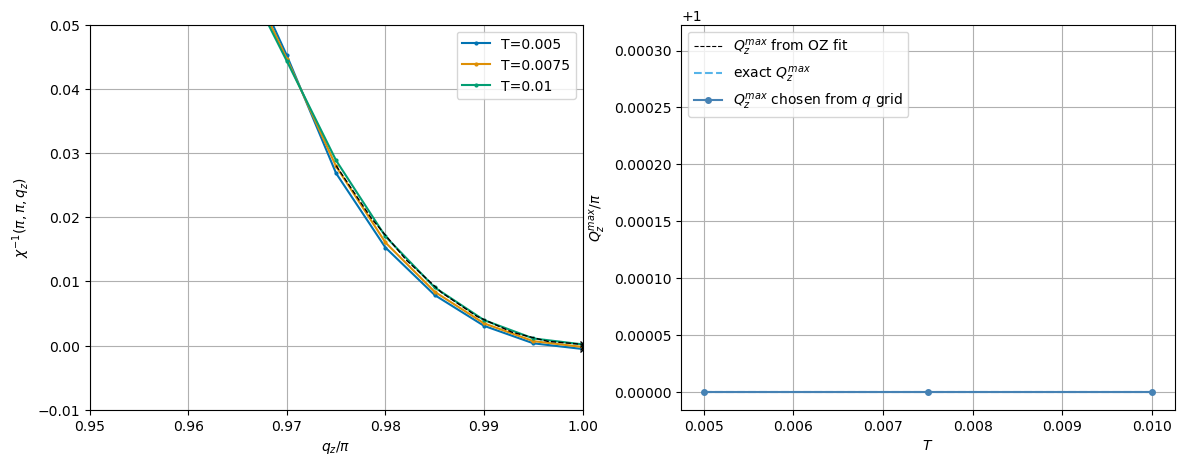

In [ ]:
n = 0.885
T_list = np.linspace(0.005, 0.01, 3)
U = 3

nk = 400
lat = LATTICE(tp=0.2)
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0.95],[1,1,1]), 'method': 'lindhard', 'get_xi': True, 'xi_range': [0,0,2.5e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')
ax[0].set_xlim(0.95, 1)
ax[0].set_ylim(-0.01, 0.05)

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z/\pi$')

q_path = ([1,1,0.95],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])
    plot_every = 1
    if i%plot_every == 0:
        ax[0].plot(qz_grid, data['invchi_grid'], 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz_ref[-1]-data['xi_range'][-1], Qz_ref[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_ref[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z$ from OZ fit')
ax[1].plot(T_list, Qz_ref, '--', color=color_list[9], label='exact $Q_z$')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z$ chosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

U: 3.000, n: 0.750: Completed 5 jobs in 2.0 seconds
U: 3.000, n: 0.750: Completed 5 jobs in 3.1 seconds
U: 3.000, n: 0.750: Completed 5 jobs in 5.1 seconds
U: 3.000, n: 0.750: Completed 5 jobs in 10.2 seconds
U: 3.000, n: 0.750: Completed 5 jobs in 2.5 seconds


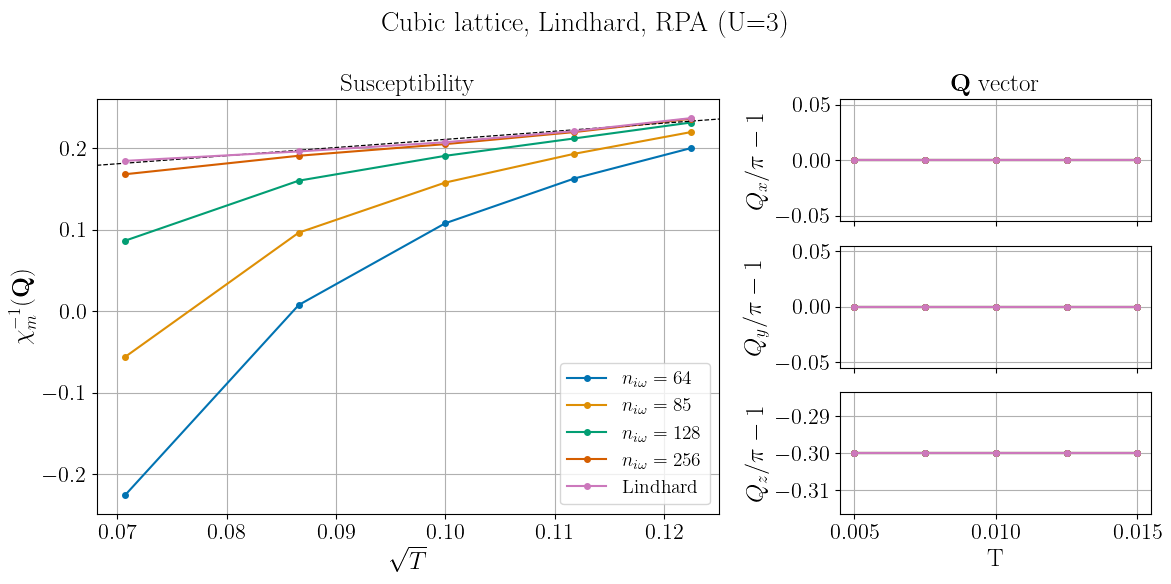

In [ ]:
U = 3
n = 0.75
T_list = np.linspace(0.005, 0.015, 5)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=100, refine=False, ibz=True)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

niw_list = [256//i for i in range(1,5)][::-1]
results_list = []
for niw in niw_list:
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=False, workers=5, xi_range=[0,0,5e-2]))

results_lindh = sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=False, workers=5, xi_range=[0,0,5e-2])

fig = None
for results in results_list:
    niw = results['niw']
    fig, _ = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=False, title=title, label=rf'$n_{{i\omega}} = {niw}$', figure=fig)
    
fig, fit = pcut_chi(results_lindh, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=True, title=title, label='Lindhard', figure=fig)

plt.show()

/home/ctort/Desktop/dmft/code/scripts/obs.py:805: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(fit, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=10000)


U: 3.000, n: 0.885: Completed 10 jobs in 7.9 seconds
U: 3.000, n: 0.885: Completed 10 jobs in 7.7 seconds
U: 3.000, n: 0.885: Completed 10 jobs in 9.3 seconds
U: 3.000, n: 0.885: Completed 10 jobs in 9.9 seconds
U: 3.000, n: 0.885: Completed 10 jobs in 9.2 seconds
U: 3.000, n: 0.885: Completed 10 jobs in 9.8 seconds


/home/ctort/Desktop/dmft/code/scripts/plot.py:443: RuntimeWarning: invalid value encountered in sqrt
  fit_xi = lambda x, a, Xc: np.sqrt(HMM(x, a, x_exp[0]/x_exp[1], Xc) * x**(2-x_exp[0]/x_exp[1]))


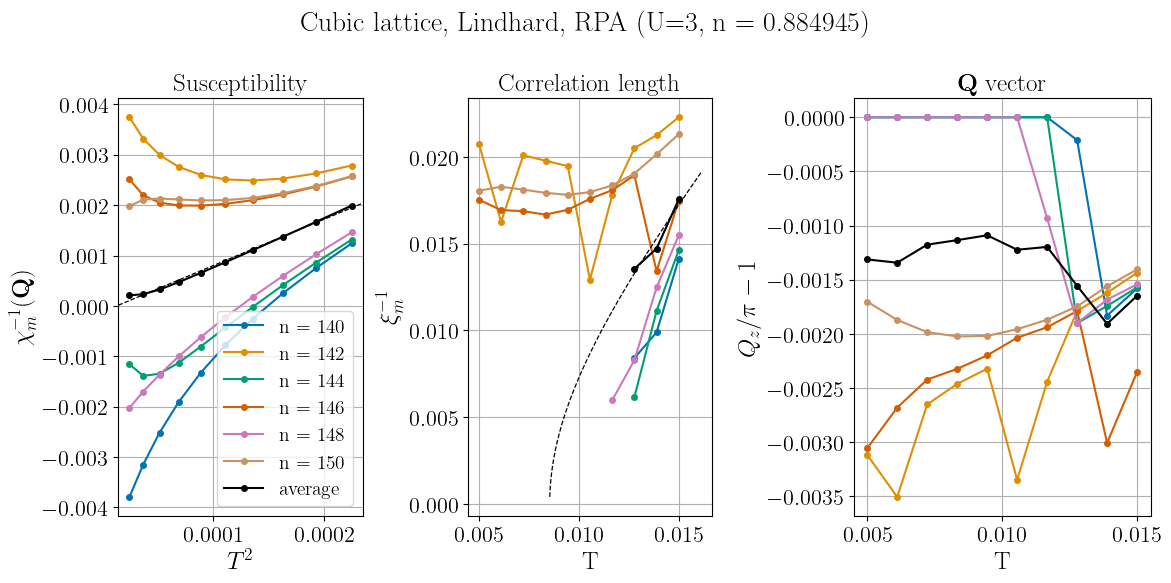

In [5]:
U = 3
n = 0.884945
T_list = np.linspace(0.005, 0.015, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U}, n = {n})'

nk_list = np.arange(140, 151, 2)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

results_list = []
for nk in nk_list:
    results_list.append(sweep_rpa(par_list, tp=0.2, nk=nk, refine=False, quad=False, xi_range=[0,0,3e-2], q_path=([1,1,0.5], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(2,1),
                        title=title, label=f'n = {nk}', figure=fig)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), x_exp=(2,1), fit=True,
                    title=title, label='average', figure=fig, color='black')

plt.show()

Starting serial run at: 2026-06-15 12:01:36.676451
Starting serial run at: 2026-06-15 12:01:36.713390
Starting serial run at: 2026-06-15 12:01:36.714024
Starting serial run at: 2026-06-15 12:01:36.727697
Starting serial run at: 2026-06-15 12:01:36.787769


n: 0.885, U: 3.000: Completed 10 jobs in 74.6 seconds
n: 0.885, U: 3.000: Completed 10 jobs in 73.9 seconds
n: 0.885, U: 3.000: Completed 10 jobs in 79.9 seconds
n: 0.885, U: 3.000: Completed 10 jobs in 81.3 seconds
n: 0.885, U: 3.000: Completed 10 jobs in 86.3 seconds
n: 0.885, U: 3.000: Completed 10 jobs in 89.3 seconds


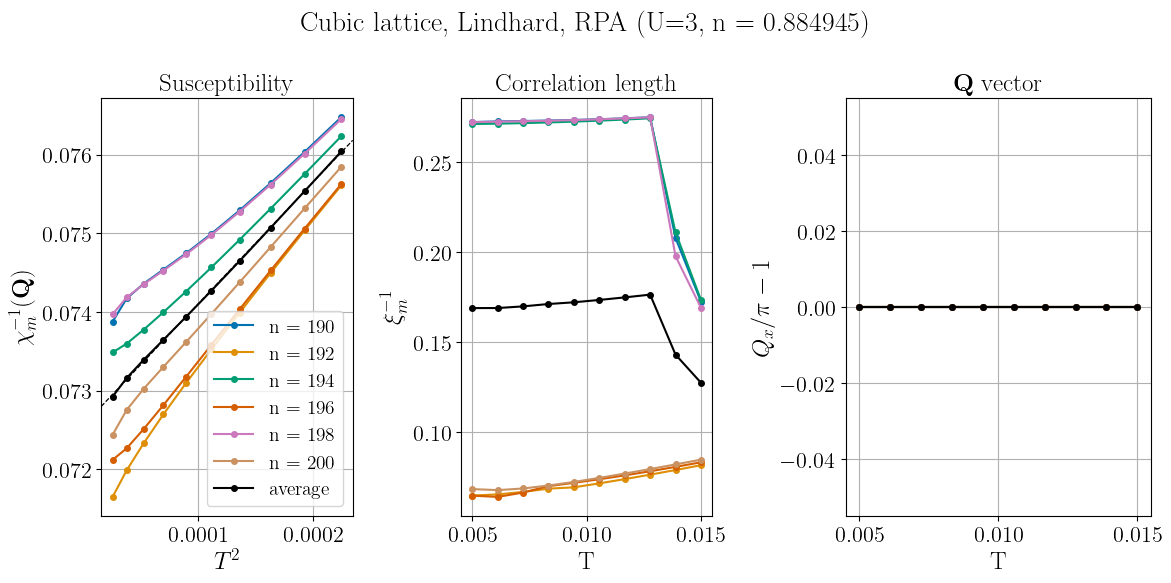

In [10]:
U = 3
n = 0.884945
T_list = np.linspace(0.005, 0.015, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U}, n = {n})'

nk_list = np.arange(190, 201, 2)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

results_list = []
for nk in nk_list:
    results_list.append(sweep_rpa(par_list, nk=nk, tp=0.2, refine=False, quad=True, xi_range=[0,0,1e-2], q_path=([1,1,0.9], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,0,0), x_exp=(2,1),
                        title=title, label=f'n = {nk}', figure=fig)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(1,0,0), x_exp=(2,1), fit=True,
                    title=title, label='average', figure=fig, color='black')

plt.show()

n: 0.885, U: 3.000: Completed 5 jobs in 40.0 seconds
n: 0.885, U: 3.000: Completed 5 jobs in 51.8 seconds
n: 0.885, U: 3.000: Completed 5 jobs in 59.2 seconds
n: 0.885, U: 3.000: Completed 5 jobs in 51.1 seconds
n: 0.885, U: 3.000: Completed 5 jobs in 47.5 seconds


/home/ctort/miniconda3/envs/triqs/lib/python3.11/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/ctort/Desktop/dmft/code/scripts/utils.py:110: RuntimeWarning: overflow encountered in scalar power
  return a * (np.sign(x) * abs(x)**b - np.sign(Xc) * abs(Xc)**b)


n: 0.885, U: 3.000: Completed 5 jobs in 57.3 seconds


/home/ctort/Desktop/dmft/code/scripts/plot.py:443: RuntimeWarning: invalid value encountered in sqrt
  fit_xi = lambda x, a, Xc: np.sqrt(HMM(x, a, x_exp[0]/x_exp[1], Xc) * x**(2-x_exp[0]/x_exp[1]))


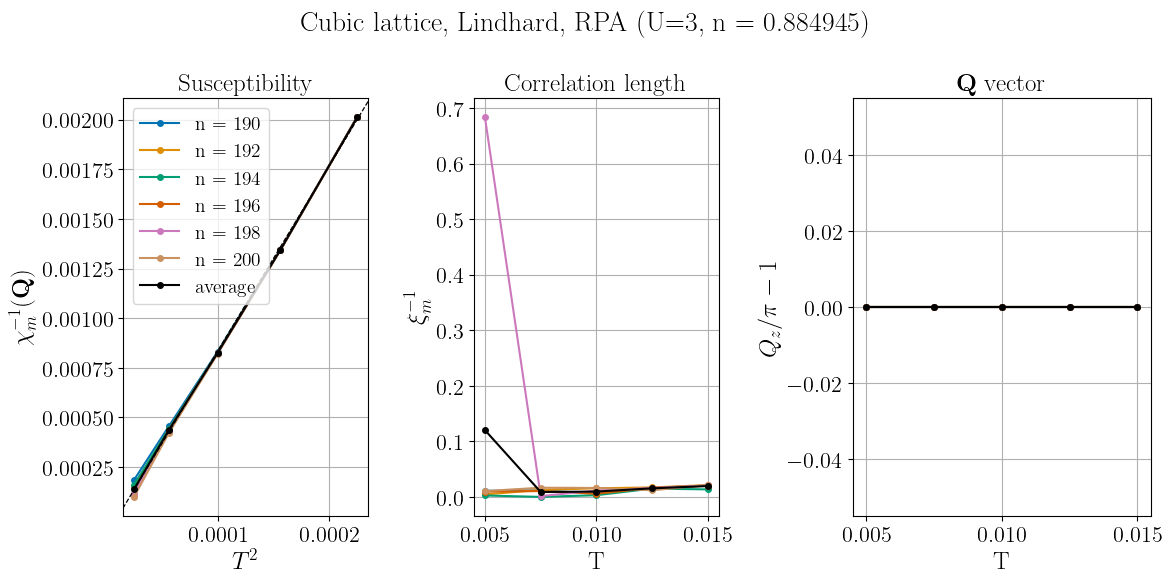

In [5]:
U = 3
n = 0.884945
T_list = np.linspace(0.005, 0.015, 5)
title = f'Cubic lattice, Lindhard, RPA (U={U}, n = {n})'

nk_list = np.arange(190, 201, 2)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

results_list = []
for nk in nk_list:
    results_list.append(sweep_rpa(par_list, tp=0.2, nk=nk, refine=True, refine_ratio=2, xi_range=[0,0,1e-2], q_path=([1,1,0.5], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(2,1),
                        title=title, label=f'n = {nk}', figure=fig)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), x_exp=(2,1), fit=True,
                    title=title, label='average', figure=fig, color='black')

plt.show()

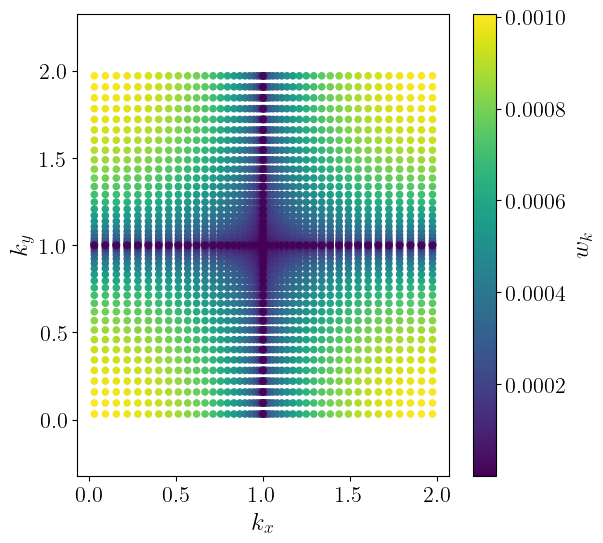

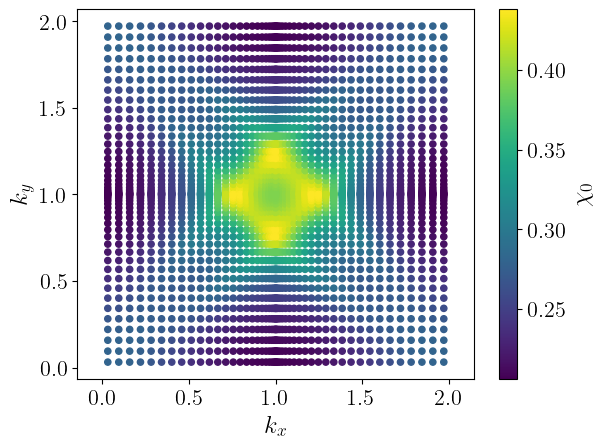

In [ ]:
nk = 50
beta = 1/0.1
n = 0.85

lat = LATTICE(dim=2, tp=0.)
initialize_bz(lat, nk, quad=True, ibz=False)

plt.figure(figsize=(6,6))

sc = plt.scatter(
    lat.k_vecs[:, 0]/np.pi,
    lat.k_vecs[:, 1]/np.pi,
    c=lat.w_k,
    s=20,
)

plt.colorbar(sc, label=r"$w_k$")
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.axis("equal")
plt.show()

kq = lat.k_vecs[:,:2]/np.pi + q[None, :2]
phase_k = np.exp(1j * np.pi * (kq @ lat.R_vecs.T))

chi0_vals = []
for q in lat.k_vecs/np.pi:
    mu = get_mu(lat.e_k, n, beta, w_k=lat.w_k)

    kq = lat.k_vecs[:,:2]/np.pi + q[None, :2]
    phases = np.exp(1j * np.pi * (kq @ lat.R_vecs.T))
    e_kq = (phases @ lat.t_vals).real

    #e_kq, _ = get_e_kq(lat.e_k, q[:2], lat.nk, method='exact', R_vecs=lat.R_vecs, t_vals=lat.t_vals)
    chi0, _ = lindhard_ksp(n, beta, lat.e_k, e_kq, [0.], [0.], quad_w_k=lat.w_k)
    chi0_vals.append(chi0)

sc = plt.scatter(
    lat.k_vecs[:, 0]/np.pi,
    lat.k_vecs[:, 1]/np.pi,
    c=chi0_vals,
    s=20,
)
plt.colorbar(sc, label=r"$\chi_0$")
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.axis("equal")
plt.show()

Starting serial run at: 2026-06-10 14:43:58.147401
Starting serial run at: 2026-06-10 14:43:58.323464


Starting serial run at: 2026-06-10 14:43:58.383274
Starting serial run at: 2026-06-10 14:43:58.431411
Starting serial run at: 2026-06-10 14:43:58.464965


n: 0.740, U: 3.000: Completed 15 jobs in 99.1 seconds
n: 0.750, U: 3.000: Completed 15 jobs in 109.2 seconds
n = 0.74 :
 chi: gamma = 0.626, Tc = -0.012, xi: nu = 0.753, Tc = 0.001
n = 0.75 :
 chi: gamma = 0.601, Tc = -0.000, xi: nu = 1.188, Tc = -0.019


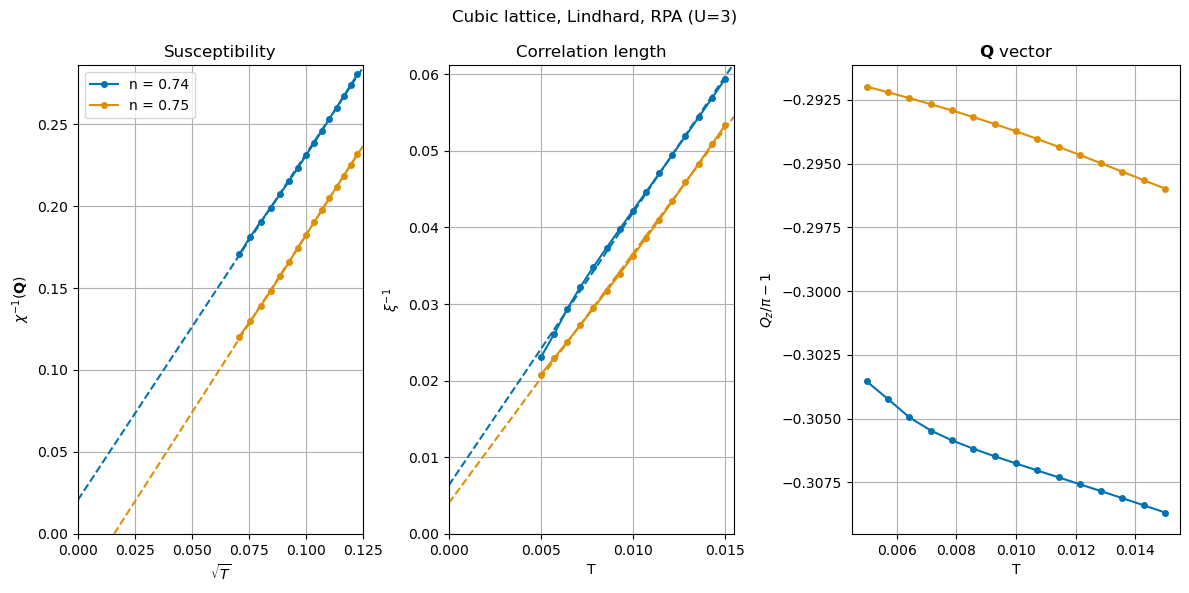

In [ ]:
U = 3
n_list = np.linspace(0.74, 0.75, 2)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=100, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, fit_grid_pts=False, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n:4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

Starting serial run at: 2026-06-06 21:26:50.524014
Starting serial run at: 2026-06-06 21:26:50.529677
Starting serial run at: 2026-06-06 21:26:50.530041
Starting serial run at: 2026-06-06 21:26:50.548214
Starting serial run at: 2026-06-06 21:26:50.587727


n: 0.760, U: 3.000: Completed 15 jobs in 1050.3 seconds
n: 0.762, U: 3.000: Completed 15 jobs in 1009.8 seconds
n: 0.765, U: 3.000: Completed 15 jobs in 995.3 seconds
n: 0.768, U: 3.000: Completed 15 jobs in 1013.1 seconds
n: 0.770, U: 3.000: Completed 15 jobs in 1011.6 seconds
n = 0.76 :
 chi: gamma = 0.723, Tc = -0.021, xi: nu = 1.081, Tc = -0.023
n = 0.7625 :
 chi: gamma = 0.723, Tc = -0.015, xi: nu = 1.065, Tc = -0.020
n = 0.765 :
 chi: gamma = 0.727, Tc = -0.011, xi: nu = 1.050, Tc = -0.017
n = 0.7675000000000001 :
 chi: gamma = 0.729, Tc = -0.007, xi: nu = 1.031, Tc = -0.013
n = 0.77 :
 chi: gamma = 0.730, Tc = -0.003, xi: nu = 1.003, Tc = -0.009


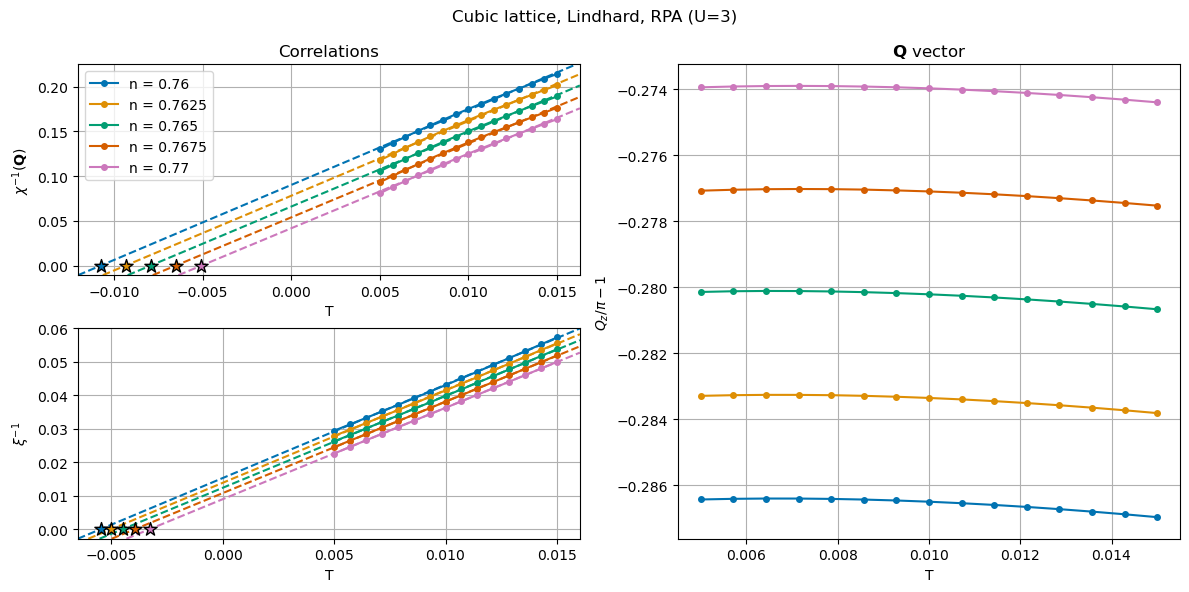

In [ ]:
U = 3
n_list = np.linspace(0.76, 0.77, 5)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.02)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

n = 0.76 :
 chi: gamma = 0.723, Tc = -0.021, xi: nu = 1.081, Tc = -0.023
n = 0.7625 :
 chi: gamma = 0.723, Tc = -0.015, xi: nu = 1.065, Tc = -0.020
n = 0.765 :
 chi: gamma = 0.727, Tc = -0.011, xi: nu = 1.050, Tc = -0.017
n = 0.7675000000000001 :
 chi: gamma = 0.729, Tc = -0.007, xi: nu = 1.031, Tc = -0.013
n = 0.77 :
 chi: gamma = 0.730, Tc = -0.003, xi: nu = 1.003, Tc = -0.009


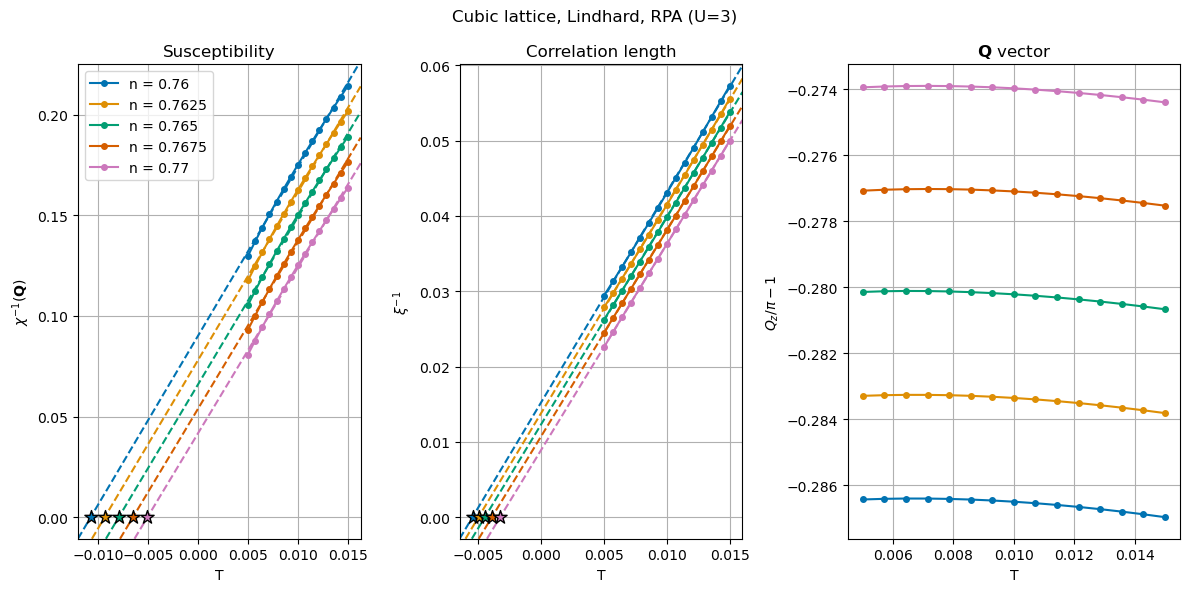

In [ ]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

U: 3.000, n: 0.760: Completed 30 jobs in 713.2 seconds
U: 3.000, n: 0.762: Completed 30 jobs in 776.5 seconds
U: 3.000, n: 0.765: Completed 30 jobs in 727.3 seconds
U: 3.000, n: 0.768: Completed 30 jobs in 707.5 seconds
U: 3.000, n: 0.770: Completed 30 jobs in 716.3 seconds
n = 0.76 :
 chi: gamma = 0.680, Tc = 0.000, xi: nu = 0.989, Tc = -0.006
n = 0.7625 :
 chi: gamma = 0.702, Tc = 0.001, xi: nu = 0.961, Tc = -0.004
n = 0.765 :
 chi: gamma = 0.729, Tc = 0.004, xi: nu = 0.897, Tc = -0.000
n = 0.7675000000000001 :
 chi: gamma = 0.727, Tc = 0.008, xi: nu = 0.837, Tc = 0.001
n = 0.77 :
 chi: gamma = 0.715, Tc = 0.012, xi: nu = 0.745, Tc = 0.002


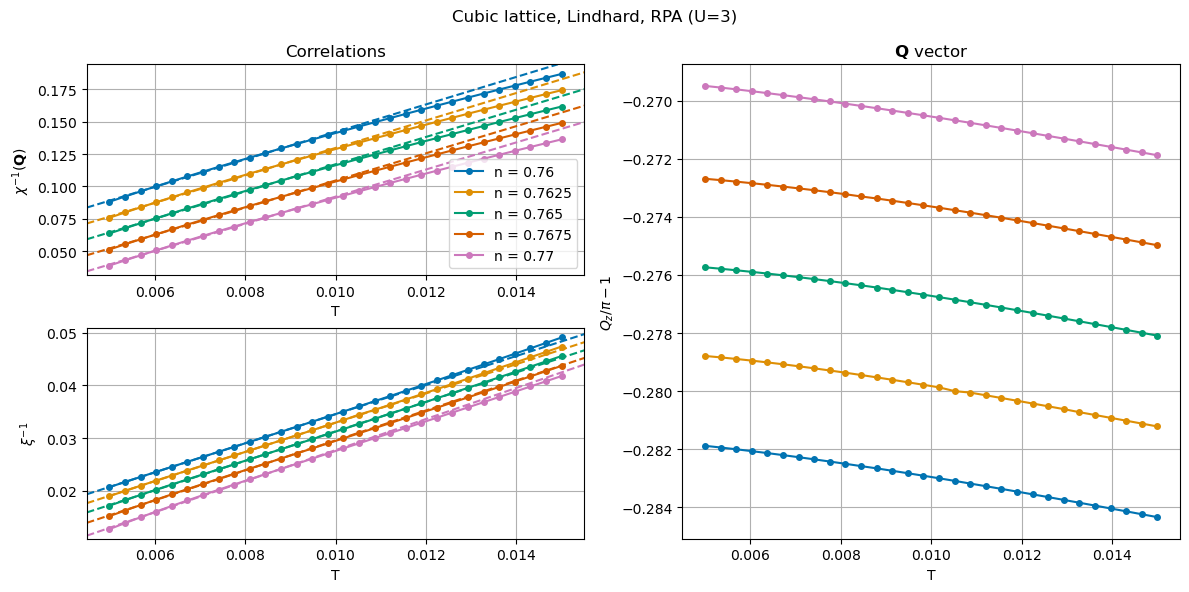

In [ ]:
U = 3
n_list = np.linspace(0.76, 0.77, 5)
T_list = np.linspace(0.005, 0.015, 30)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.01)
initialize_bz(lat, nk=150, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

U: 3.000, n: 0.886: Completed 15 jobs in 518.2 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 522.7 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 491.8 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 471.0 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 470.8 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 454.5 seconds
n = 0.8865 :
 chi: gamma = 1.014, Tc = -0.007, xi: nu = 1.363, Tc = -0.041
n = 0.8866999999999999 :
 chi: gamma = 0.968, Tc = -0.004, xi: nu = 1.325, Tc = -0.032
n = 0.8868999999999999 :
 chi: gamma = 0.379, Tc = 0.000, xi: nu = 0.466, Tc = 0.000
n = 0.8871 :
 chi: gamma = 1.502, Tc = -0.033, xi: nu = 0.766, Tc = -0.000
n = 0.8873 :
 chi: gamma = 2.170, Tc = -0.081, xi: nu = 1.595, Tc = -0.063
n = 0.8875 :
 chi: gamma = 1.672, Tc = -0.003, xi: nu = 1.830, Tc = -0.068


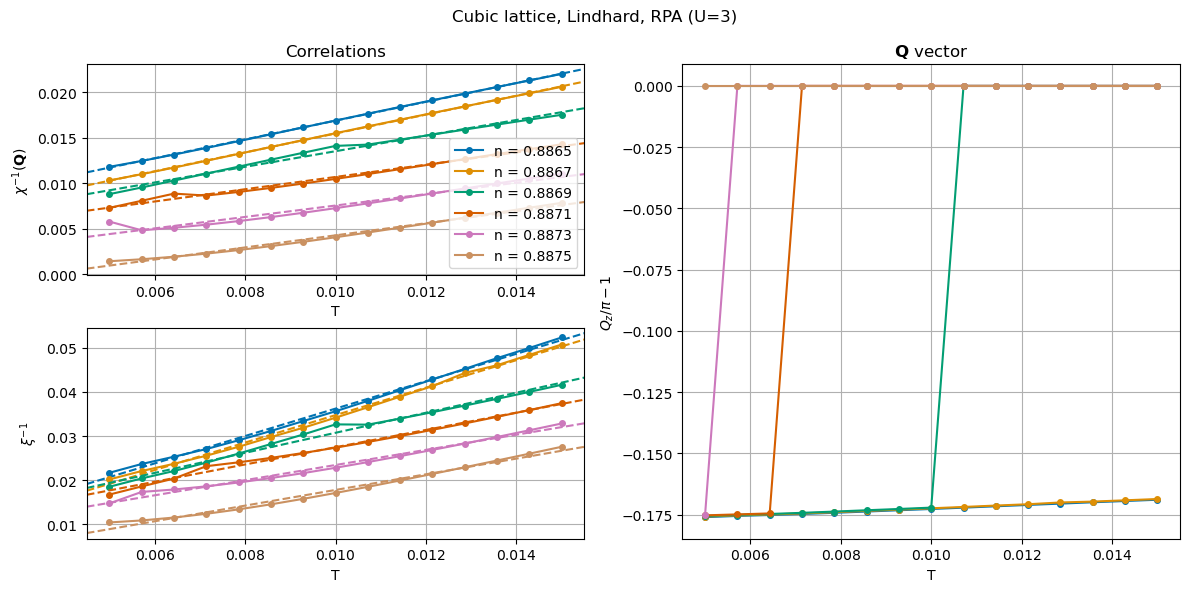

In [ ]:
U = 3
n_list = np.linspace(0.8865, 0.8875, 6)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.172)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=3/2)

niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

n: 0.735, U: 3.000: Completed 15 jobs in 676.4 seconds
n: 0.740, U: 3.000: Completed 15 jobs in 666.8 seconds
n: 0.745, U: 3.000: Completed 15 jobs in 701.6 seconds
n: 0.750, U: 3.000: Completed 15 jobs in 684.8 seconds
n: 0.755, U: 3.000: Completed 15 jobs in 714.2 seconds
n = 0.735 :
 chi: gamma = 0.385, Tc = -0.000, xi: nu = 1.045, Tc = -0.003
n = 0.74 :
 chi: gamma = 0.405, Tc = -0.000, xi: nu = 1.037, Tc = -0.002
n = 0.745 :
 chi: gamma = 0.509, Tc = 0.000, xi: nu = 1.027, Tc = -0.002
n = 0.75 :
 chi: gamma = 0.564, Tc = 0.000, xi: nu = 1.038, Tc = -0.001
n = 0.755 :
 chi: gamma = 0.540, Tc = 0.000, xi: nu = 0.999, Tc = -0.000


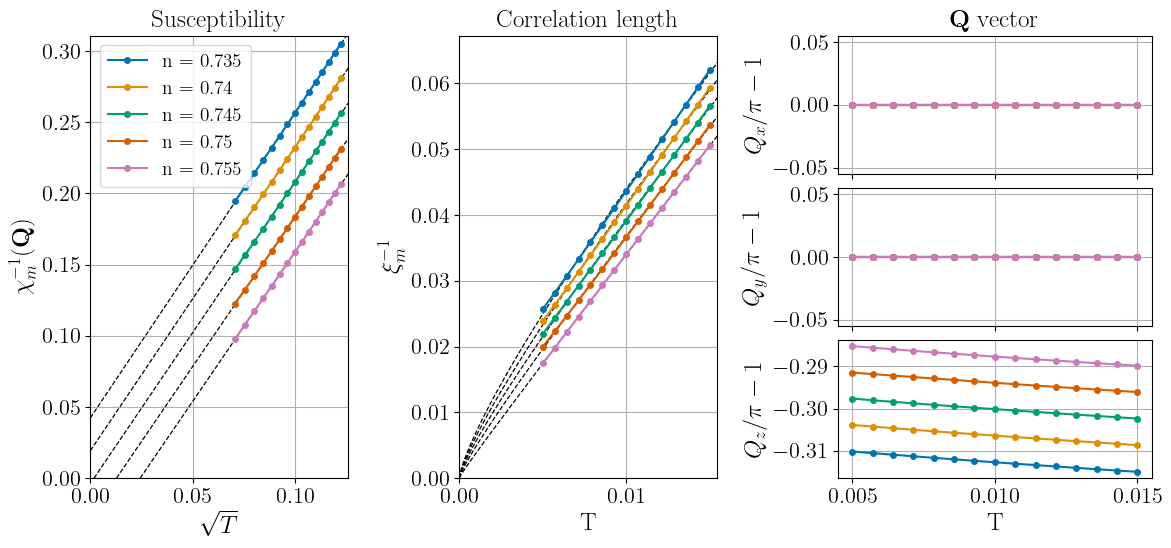

In [62]:
U = 3
n_list = np.linspace(0.735, 0.755, 5)
T_list = np.linspace(0.005, 0.015, 15)

lat = LATTICE()
initialize_bz(lat, nk=200, refine=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.6],[1,1,1]), method='local', get_xi=True, fit=True, fit_grid_pts=False, workers=5))

x_exp = (0.5,1)
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=x_exp, fit=True, label=f'n = {n:.6g}', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

n: 0.846, U: 3.000: Completed 15 jobs in 626.9 seconds
n: 0.847, U: 3.000: Completed 15 jobs in 644.7 seconds
n: 0.848, U: 3.000: Completed 15 jobs in 639.0 seconds
n: 0.849, U: 3.000: Completed 15 jobs in 629.1 seconds
n: 0.850, U: 3.000: Completed 15 jobs in 627.5 seconds
n = 0.846 :
 chi: gamma = 1.013, Tc = -0.005, xi: nu = 1.121, Tc = -0.006
n = 0.847 :
 chi: gamma = 1.005, Tc = -0.003, xi: nu = 1.088, Tc = -0.004
n = 0.848 :
 chi: gamma = 0.994, Tc = -0.001, xi: nu = 1.032, Tc = -0.002
n = 0.849 :
 chi: gamma = 0.989, Tc = 0.002, xi: nu = 0.946, Tc = 0.001
n = 0.85 :
 chi: gamma = 0.992, Tc = 0.004, xi: nu = 0.794, Tc = 0.003


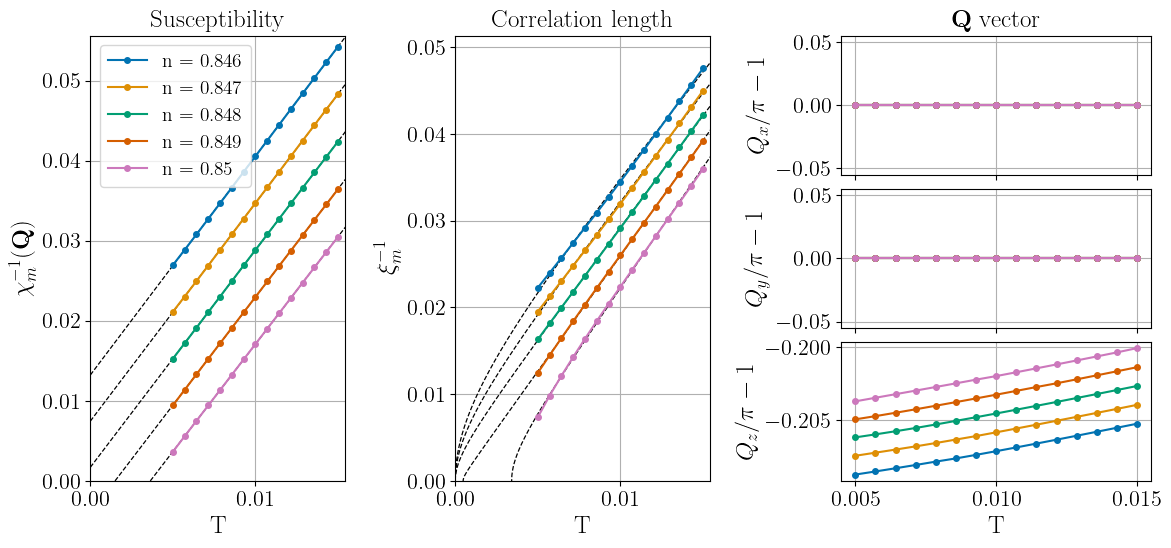

In [63]:
U = 3
n_list = np.linspace(0.846, 0.85, 5)
T_list = np.linspace(0.005, 0.015, 15)

lat = LATTICE(tp=0.1)
initialize_bz(lat, nk=200, refine=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.7],[1,1,1]), method='local', get_xi=True, fit=True, fit_grid_pts=False, workers=5))

x_exp = (1,1)
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=x_exp, fit=True, label=f'n = {n:.6g}', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

n: 0.885, U: 3.000: Completed 15 jobs in 428.5 seconds
n: 0.885, U: 3.000: Completed 15 jobs in 426.5 seconds
n: 0.885, U: 3.000: Completed 15 jobs in 425.1 seconds
n: 0.885, U: 3.000: Completed 15 jobs in 425.8 seconds
n: 0.885, U: 3.000: Completed 15 jobs in 427.4 seconds
n = 0.884905 :
 chi: gamma = 2.012, Tc = -0.006, xi: nu = 1.082, Tc = -0.007
n = 0.88492 :
 chi: gamma = 1.673, Tc = -0.000, xi: nu = 0.940, Tc = -0.002
n = 0.884935 :
 chi: gamma = 2.009, Tc = -0.000, xi: nu = 0.724, Tc = 0.001
n = 0.88495 :
 chi: gamma = 2.007, Tc = 0.004, xi: nu = 0.278, Tc = 0.004
n = 0.884965 :
 chi: gamma = 2.102, Tc = 0.006, xi: nu = 0.021, Tc = 0.005


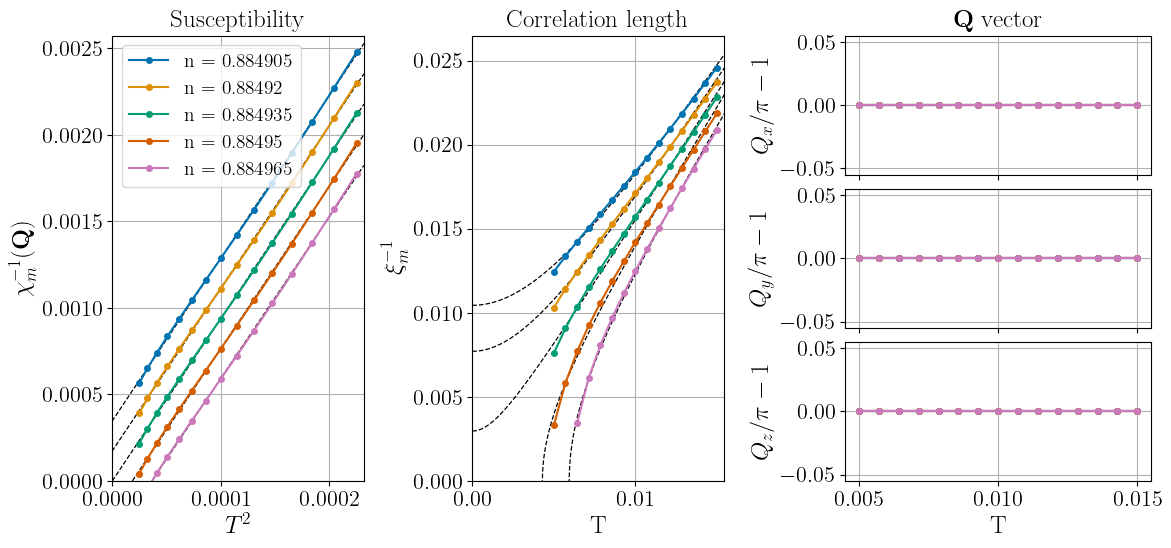

In [64]:
U = 3
n_list = np.linspace(0.884905, 0.884965, 5)
T_list = np.linspace(0.005, 0.015, 15)

lat = LATTICE(tp=0.2)
initialize_bz(lat, nk=200, refine=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.98],[1,1,1]), method='local', get_xi=True, fit=True, fit_grid_pts=False, workers=5))

x_exp = (2,1)
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=x_exp, fit=True, label=f'n = {n:.6g}', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

Starting serial run at: 2026-06-17 01:25:35.990065
Starting serial run at: 2026-06-17 01:25:36.001687
Starting serial run at: 2026-06-17 01:25:36.050457
Starting serial run at: 2026-06-17 01:25:36.093508


Starting serial run at: 2026-06-17 01:25:36.191719


U: 3.000, n: 0.730: Completed 20 jobs in 329.7 seconds
U: 3.000, n: 0.738: Completed 20 jobs in 378.6 seconds
U: 3.000, n: 0.746: Completed 20 jobs in 342.5 seconds
U: 3.000, n: 0.753: Completed 20 jobs in 344.5 seconds
U: 3.000, n: 0.761: Completed 20 jobs in 355.2 seconds
U: 3.000, n: 0.769: Completed 20 jobs in 388.6 seconds
U: 3.000, n: 0.777: Completed 20 jobs in 332.2 seconds
U: 3.000, n: 0.785: Completed 20 jobs in 347.3 seconds
U: 3.000, n: 0.793: Completed 20 jobs in 333.9 seconds
U: 3.000, n: 0.800: Completed 20 jobs in 383.5 seconds
U: 3.000, n: 0.808: Completed 20 jobs in 324.4 seconds
U: 3.000, n: 0.816: Completed 20 jobs in 339.1 seconds
U: 3.000, n: 0.824: Completed 20 jobs in 331.3 seconds
U: 3.000, n: 0.832: Completed 20 jobs in 341.6 seconds
U: 3.000, n: 0.840: Completed 20 jobs in 333.8 seconds
U: 3.000, n: 0.847: Completed 20 jobs in 329.4 seconds
U: 3.000, n: 0.855: Completed 20 jobs in 305.4 seconds
U: 3.000, n: 0.863: Completed 20 jobs in 300.3 seconds
U: 3.000, 

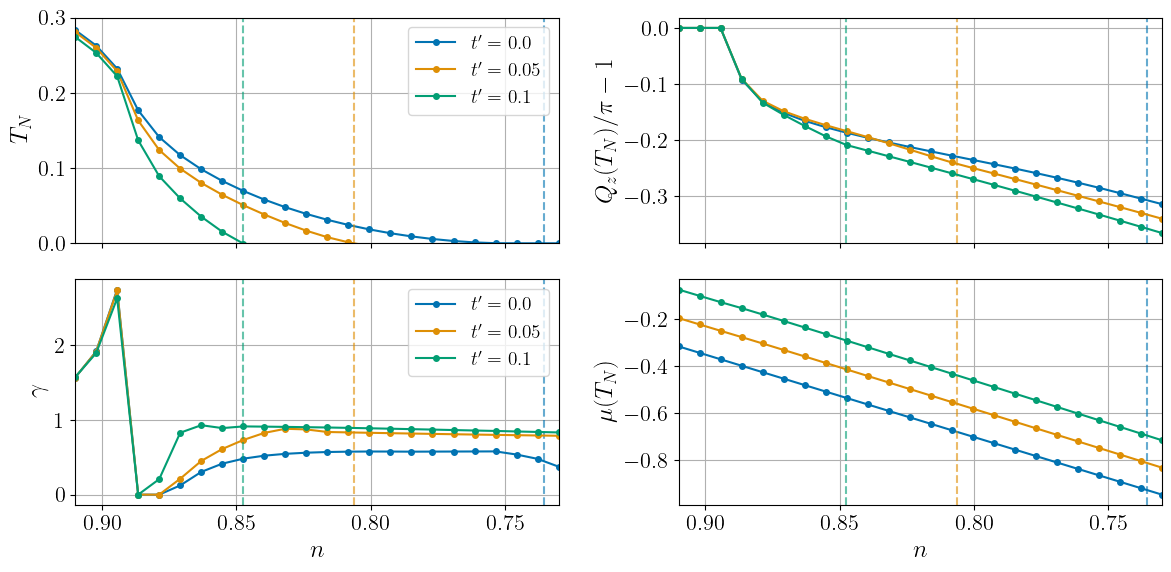

In [31]:
n_old = n_list1

U = 3
n_list1 = np.linspace(0.73, 0.91, 24)
T_list = np.linspace(0., 0.06, 20)

#prev_Tc1 = np.zeros((3, len(n_list1)))
prev_Tc1 = [np.interp(n_list1, n_old, Tc1[j][:]) for j in range(3)]

nk = 200
tp_list = [0., 0.05, 0.1]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

fig = plt.figure(figsize=(12, 6))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
fig.subplots_adjust(hspace=0.15, wspace=0.03)

for a in ax:
    a.grid()
    a.set_xlim(n_list1[0], n_list1[-1])
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel(r'$T_N$')
ax[1].set_ylabel(r'$\gamma$')
ax[2].set_ylabel(r'$Q_z(T_N)/\pi - 1$')
ax[3].set_ylabel(r'$\mu(T_N)$')

ax[0].tick_params(axis='x', labelbottom=False)
ax[2].tick_params(axis='x', labelbottom=False)
ax[1].set_xlabel(r'$n$')
ax[3].set_xlabel(r'$n$')

Tc1 = prev_Tc1.copy()
for j, tp in enumerate(tp_list):

    lat = LATTICE(tp=tp)
    initialize_bz(lat, nk, refine=True, refine_ratio=2)

    results_list = []
    for i, n in enumerate(n_list1):
        par_list = [{'U': U, 'n': n, 'T': T} for T in  T_list + max(prev_Tc1[j][i], 0.01)]
        results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.5],[1,1,1]), method='local', get_xi=False, fit=True, workers=5))

    Tc1[j][:] = [res['fitchi']['Xc'] for res in results_list]
    gamma = [res['fitchi']['b'] for res in results_list]
    Qc = [res['Qc'][-1]-1 for res in results_list]
    muc = [res['mu_c'][0] for res in results_list]

    line = ax[0].plot(n_list1, Tc1[j][:], 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[1].plot(n_list1, gamma, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[2].plot(n_list1, Qc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[3].plot(n_list1, muc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])

    nc = np.interp(0., Tc1[j][:], n_list1)
    for a in ax:
        a.axvline(nc, linestyle='--', color=color_list[j], alpha=0.6)

ax[0].legend()
ax[1].legend()

print(Tc1)
fig.tight_layout()
plt.show()

Starting serial run at: 2026-06-17 07:57:17.109770
Starting serial run at: 2026-06-17 07:57:17.162639
Starting serial run at: 2026-06-17 07:57:17.168013
Starting serial run at: 2026-06-17 07:57:17.219315
Starting serial run at: 2026-06-17 07:57:17.285051


U: 3.000, n: 0.870: Completed 20 jobs in 77.3 seconds
U: 3.000, n: 0.872: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.873: Completed 20 jobs in 74.5 seconds
U: 3.000, n: 0.875: Completed 20 jobs in 74.1 seconds
U: 3.000, n: 0.877: Completed 20 jobs in 78.8 seconds
U: 3.000, n: 0.879: Completed 20 jobs in 76.9 seconds
U: 3.000, n: 0.880: Completed 20 jobs in 80.7 seconds
U: 3.000, n: 0.882: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.884: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.886: Completed 20 jobs in 72.6 seconds
U: 3.000, n: 0.887: Completed 20 jobs in 70.7 seconds
U: 3.000, n: 0.889: Completed 20 jobs in 40.5 seconds
U: 3.000, n: 0.891: Completed 20 jobs in 40.4 seconds
U: 3.000, n: 0.893: Completed 20 jobs in 40.2 seconds
U: 3.000, n: 0.894: Completed 20 jobs in 39.7 seconds
U: 3.000, n: 0.896: Completed 20 jobs in 40.0 seconds
U: 3.000, n: 0.898: Completed 20 jobs in 39.6 seconds
U: 3.000, n: 0.900: Completed 20 jobs in 40.0 seconds
U: 3.000, n: 0.901: Complete

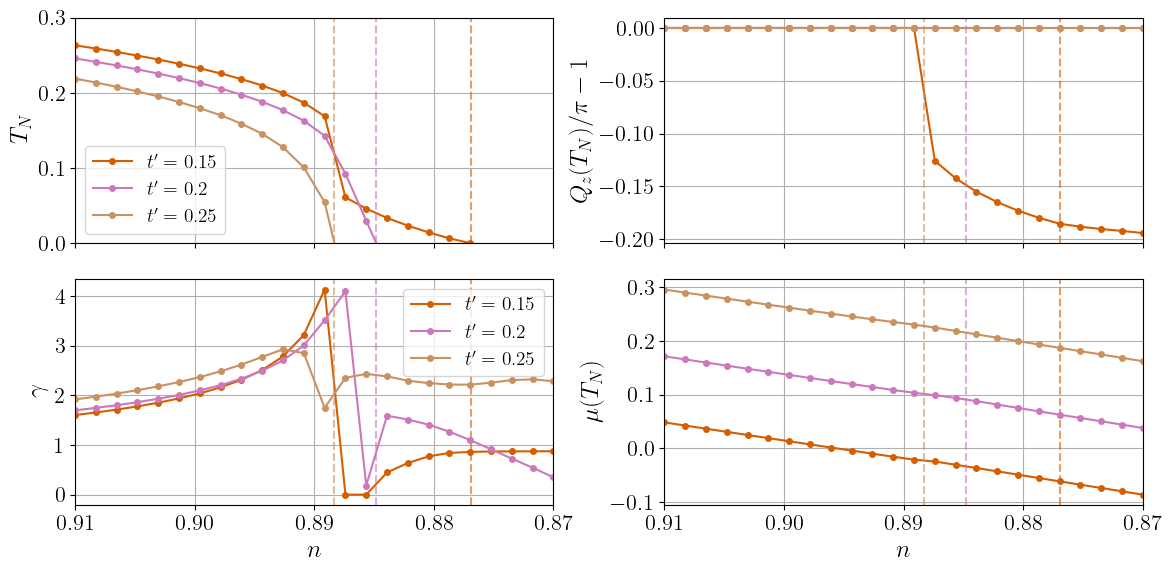

In [32]:
n_old = n_list2

U = 3
n_list2 = np.linspace(0.87, 0.91, 24)
T_list = np.linspace(0., 0.06, 20)

#prev_Tc2 = np.zeros((3, len(n_list2)))
prev_Tc2 = [np.interp(n_list2, n_old, Tc2[j][:]) for j in range(3)]

nk = 130
tp_list = [0.15, 0.2, 0.25]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

fig = plt.figure(figsize=(12, 6))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
fig.subplots_adjust(hspace=0.15, wspace=0.03)

for a in ax:
    a.grid()
    a.set_xlim(n_list2[0], n_list2[-1])
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel(r'$T_N$')
ax[1].set_ylabel(r'$\gamma$')
ax[2].set_ylabel(r'$Q_z(T_N)/\pi - 1$')
ax[3].set_ylabel(r'$\mu(T_N)$')

ax[0].tick_params(axis='x', labelbottom=False)
ax[2].tick_params(axis='x', labelbottom=False)
ax[1].set_xlabel(r'$n$')
ax[3].set_xlabel(r'$n$')

Tc2 = prev_Tc2.copy()
for j, tp in enumerate(tp_list):

    lat = LATTICE(tp=tp)
    initialize_bz(lat, nk, refine=True, refine_ratio=2)

    results_list = []
    for i, n in enumerate(n_list2):
        par_list = [{'U': U, 'n': n, 'T': T} for T in  T_list + max(prev_Tc2[j][i], 0.01)]
        results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.5],[1,1,1]), method='local', get_xi=False, fit=True, workers=5))

    Tc2[j][:] = [res['fitchi']['Xc'] for res in results_list]
    gamma = [res['fitchi']['b'] for res in results_list]
    Qc = [res['Qc'][-1]-1 for res in results_list]
    muc = [res['mu_c'][0] for res in results_list]

    line = ax[0].plot(n_list2, Tc2[j][:], 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[1].plot(n_list2, gamma, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[2].plot(n_list2, Qc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[3].plot(n_list2, muc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])

    nc = np.interp(0., Tc2[j][:], n_list2)
    for a in ax:
        a.axvline(nc, linestyle='--', color=color_list[3+j], alpha=0.6)

ax[0].legend()
ax[1].legend()

print(Tc2)
fig.tight_layout()
plt.show()

In [ ]:
print(Tc2)

[array([-0.02045428, -0.00856195, -0.00181113,  0.00072029,  0.00433789,
        0.00913734,  0.01594448,  0.02495022,  0.03089112,  0.03467473,
        0.06234645,  0.17024629,  0.18772693,  0.20011302,  0.21009421,
        0.21859773,  0.2260738 ,  0.23278102,  0.23888397,  0.24449499,
        0.24969475,  0.2545435 ,  0.25908759,  0.26336362]), array([-2.71161010e+00, -4.63290823e-09, -4.13293660e-09, -3.50764123e-09,
       -3.73939104e-09, -2.36405673e-09, -4.70965173e-09, -3.16401004e-09,
        3.90415541e-03,  2.80938604e-02,  9.46925382e-02,  1.43783428e-01,
        1.63522252e-01,  1.77406248e-01,  1.88469281e-01,  1.97807380e-01,
        2.05956197e-01,  2.13222814e-01,  2.19801762e-01,  2.25825044e-01,
        2.31386941e-01,  2.36557447e-01,  2.41390173e-01,  2.45927208e-01]), array([-0.37898587, -0.33547605, -0.29726989, -0.26570991, -0.23833888,
       -0.21153674, -0.18410591, -0.15709071, -0.1308355 , -0.10275311,
       -0.06399933,  0.04803951,  0.10143376,  0.12822